# **Parallal Workflow**

In [1]:
import os
from typing import TypedDict
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage
from langgraph.graph import START, END, StateGraph

# 1. Define the Shared State
class TechAnalysisState(TypedDict):
    topic: str
    pros: str
    cons: str
    verdict: str

llm = ChatGroq(model_name="openai/gpt-oss-120b", temperature=0.5)

# 2. Define the Nodes
def analyze_pros(state: TechAnalysisState) -> TechAnalysisState:
    print("⚡ [Groq] Analyzing the Pros...")
    prompt = f"List 2 major advantages or benefits of: {state['topic']}. Keep it concise."
    response = llm.invoke([HumanMessage(content=prompt)])
    return {"pros": response.content}

def analyze_cons(state: TechAnalysisState) -> TechAnalysisState:
    print("⚡ [Groq] Analyzing the Cons...")
    prompt = f"List 2 major risks, downsides, or challenges of: {state['topic']}. Keep it concise."
    response = llm.invoke([HumanMessage(content=prompt)])
    return {"cons": response.content}

def generate_verdict(state: TechAnalysisState) -> TechAnalysisState:
    print("🧠 [Groq] Generating final verdict...")
    prompt = (
        f"Based on the following points for '{state['topic']}', provide a 1-sentence final verdict.\n\n"
        f"PROS:\n{state['pros']}\n\n"
        f"CONS:\n{state['cons']}"
    )
    response = llm.invoke([HumanMessage(content=prompt)])
    return {"verdict": response.content}

# 3. Build the Graph
builder = StateGraph(TechAnalysisState)

# Add nodes
builder.add_node("pros_node", analyze_pros)
builder.add_node("cons_node", analyze_cons)
builder.add_node("verdict_node", generate_verdict)

# 4. Define Parallel Split (Fan-Out)
# Both nodes fire concurrently on Groq hardware
builder.add_edge(START, "pros_node")
builder.add_edge(START, "cons_node")

# 5. Define Join (Fan-In)
# Verdict node waits for both parallel branches to complete
builder.add_edge("pros_node", "verdict_node")
builder.add_edge("cons_node", "verdict_node")

builder.add_edge("verdict_node", END)

# 6. Compile and Run
graph = builder.compile()
inputs = {"topic": "Serverless Computing for Startup MVPs"}
print("--- Launching Parallel Groq Workflow ---")
result = graph.invoke(inputs)

print("\n--- Final Verdict ---")
print(result["verdict"])


--- Launching Parallel Groq Workflow ---
⚡ [Groq] Analyzing the Cons...
⚡ [Groq] Analyzing the Pros...
🧠 [Groq] Generating final verdict...

--- Final Verdict ---
Overall, the rapid development and pay‑as‑you‑go scalability of serverless usually outweigh its cold‑start latency and vendor‑lock‑in concerns—so it’s a strong fit for most startup MVPs as long as you design for occasional latency spikes and keep a migration strategy in mind.


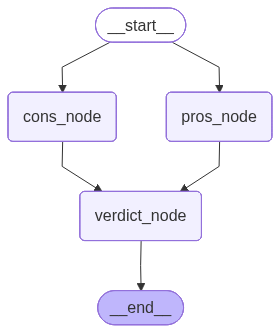

In [2]:
graph

# **Another Example**

### **UPSC Essay reviewing tool**

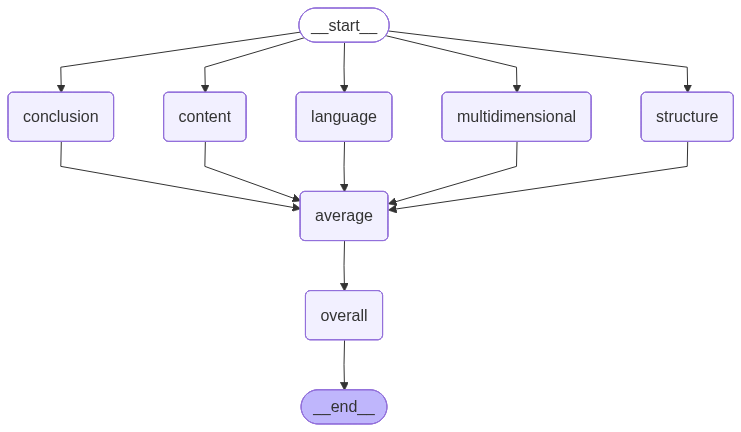

BadRequestError: Error code: 400 - {'error': {'message': 'Tool call validation failed: tool call validation failed: parameters for tool EvaluationSchema did not match schema: errors: [`/score`: expected integer, but got number]', 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '{"name": "EvaluationSchema", "arguments": {\n  "feedback": "### Feedback on Conclusion & Way Forward\\n\\n**Strengths**\\n1. **Clear Summation** – The essay ends with a concise restatement of the central thesis – that technology can be a servant or a master – which helps the reader recall the main argument.\\n2. **Visionary Tone** – You project a forward‑looking vision of a \\"balanced digital ecosystem\\" where policy, ethics and citizen awareness co‑exist. This aligns with the UPSC expectation of a macro‑level perspective.\\n3. **Optimistic Outlook** – The concluding paragraph ends on a hopeful note, emphasizing that \\"human agency, when guided by foresight, can harness techno

In [9]:
from typing import TypedDict, Annotated, List
import operator

from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from IPython.display import Image, display

# ============================================================
# LLM
# ============================================================

llm = ChatGroq(
    model_name="openai/gpt-oss-120b",
    temperature=0.5
)


# ============================================================
# STATE
# ============================================================

class UPSCState(TypedDict):
    essay: str

    language_feedback: str
    content_feedback: str
    structure_feedback: str
    multidimensional_feedback: str
    conclusion_feedback: str

    overall_feedback: str

    individual_scores: Annotated[List[int], operator.add] # reducer to sum scores
    avg_score: float


# ============================================================
# OUTPUT SCHEMA
# ============================================================

class EvaluationSchema(BaseModel):
    feedback: str = Field(
        description="Detailed constructive UPSC-style feedback"
    )

    score: int = Field(
        description="Score out of 10",
        ge=0,
        le=10
    )


structured_llm = llm.with_structured_output(EvaluationSchema)


# ============================================================
# COMMON PROMPT
# ============================================================

evaluation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
You are a senior UPSC Essay Evaluator.

Your task is to evaluate an essay on ONE specific criterion.

Instructions:
1. Evaluate critically but fairly.
2. Mention strengths.
3. Mention weaknesses.
4. Suggest actionable improvements.
5. Follow UPSC standards.
6. Give a score between 0 and 10.

Return detailed feedback.
"""
        ),
        (
            "human",
            """
Criterion:
{criterion}

Essay:
{essay}
"""
        )
    ]
)


# ============================================================
# GENERIC EVALUATOR
# ============================================================

def evaluate_dimension(
    essay: str,
    criterion: str
) -> EvaluationSchema:

    chain = evaluation_prompt | structured_llm

    return chain.invoke(
        {
            "criterion": criterion,
            "essay": essay
        }
    )


# ============================================================
# EVALUATORS
# ============================================================

def evaluate_language(state: UPSCState):

    result = evaluate_dimension(
        essay=state["essay"],
        criterion="""
Language & Expression

Evaluate:
- Grammar
- Vocabulary
- Sentence construction
- Readability
- Professional tone
"""
    )

    return {
        "language_feedback": result.feedback,
        "individual_scores": [result.score]
    }


def evaluate_content(state: UPSCState):

    result = evaluate_dimension(
        essay=state["essay"],
        criterion="""
Content Depth

Evaluate:
- Knowledge richness
- Relevance
- Examples
- Facts and illustrations
- Subject understanding
"""
    )

    return {
        "content_feedback": result.feedback,
        "individual_scores": [result.score]
    }


def evaluate_structure(state: UPSCState):

    result = evaluate_dimension(
        essay=state["essay"],
        criterion="""
Structure & Flow

Evaluate:
- Introduction
- Paragraph organization
- Logical progression
- Cohesion
- Overall flow
"""
    )

    return {
        "structure_feedback": result.feedback,
        "individual_scores": [result.score]
    }


def evaluate_multidimensional(state: UPSCState):

    result = evaluate_dimension(
        essay=state["essay"],
        criterion="""
Multi-Dimensional Analysis

Evaluate:
- Social perspective
- Political perspective
- Economic perspective
- Ethical perspective
- Environmental perspective
- Historical perspective

Assess how well the essay explores multiple dimensions.
"""
    )

    return {
        "multidimensional_feedback": result.feedback,
        "individual_scores": [result.score]
    }


def evaluate_conclusion(state: UPSCState):

    result = evaluate_dimension(
        essay=state["essay"],
        criterion="""
Conclusion & Way Forward

Evaluate:
- Strength of conclusion
- Vision
- Optimism
- Practical recommendations
- UPSC-style maturity
"""
    )

    return {
        "conclusion_feedback": result.feedback,
        "individual_scores": [result.score]
    }


# ============================================================
# SCORE AGGREGATION
# ============================================================

def calculate_average_score(state: UPSCState):

    scores = state["individual_scores"]

    avg = round(sum(scores) / len(scores), 2)

    return {
        "avg_score": avg
    }


# ============================================================
# OVERALL FEEDBACK
# ============================================================

overall_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
You are a highly experienced UPSC Essay Mentor.

Using all evaluation reports:

Generate:
1. Overall Assessment
2. Top Strengths
3. Key Weaknesses
4. Improvement Roadmap
5. Final Verdict

The feedback should be detailed,
actionable and UPSC-focused.
"""
        ),
        (
            "human",
            """
Language Evaluation:
{language}

Content Evaluation:
{content}

Structure Evaluation:
{structure}

Multi-Dimensional Evaluation:
{multidimensional}

Conclusion Evaluation:
{conclusion}

Average Score:
{score}/10
"""
        )
    ]
)


def generate_overall_feedback(state: UPSCState):

    chain = overall_prompt | llm

    response = chain.invoke(
        {
            "language": state["language_feedback"],
            "content": state["content_feedback"],
            "structure": state["structure_feedback"],
            "multidimensional": state["multidimensional_feedback"],
            "conclusion": state["conclusion_feedback"],
            "score": state["avg_score"]
        }
    )

    return {
        "overall_feedback": response.content
    }


# ============================================================
# LANGGRAPH WORKFLOW
# ============================================================

builder = StateGraph(UPSCState)

builder.add_node("language", evaluate_language)
builder.add_node("content", evaluate_content)
builder.add_node("structure", evaluate_structure)
builder.add_node("multidimensional", evaluate_multidimensional)
builder.add_node("conclusion", evaluate_conclusion)
builder.add_node("average", calculate_average_score)
builder.add_node("overall", generate_overall_feedback)

builder.add_edge(START, "language")
builder.add_edge(START, "content")
builder.add_edge(START, "structure")
builder.add_edge(START, "multidimensional")
builder.add_edge(START, "conclusion")

builder.add_edge("language", "average")
builder.add_edge("content", "average")
builder.add_edge("structure", "average")
builder.add_edge("multidimensional", "average")
builder.add_edge("conclusion", "average")

builder.add_edge("average", "overall")
builder.add_edge("overall", END)

graph = builder.compile()
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

# ============================================================
# RUN
# ============================================================

essay = """
Technology is a useful servant but a dangerous master.
(Your UPSC Essay Here)
"""

result = graph.invoke(
    {
        "essay": essay,
        "individual_scores": []
    }
)

print("\n" + "=" * 80)
print("AVERAGE SCORE")
print("=" * 80)
print(result["avg_score"])

print("\n" + "=" * 80)
print("OVERALL FEEDBACK")
print("=" * 80)
print(result["overall_feedback"])